In [ ]:
import os
import sys
import re
import numpy as np
import pandas as pd
import plotly.express as px
import scipy.stats as stats
from dash import html, dcc, Input, Output, Dash
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ast import literal_eval

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_validate
import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import GroupKFold

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRAT_GROUP_KFOLD = True
except ImportError:
    HAS_STRAT_GROUP_KFOLD = False

sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))
from baseVR.base_functionality import init_import_paths
init_import_paths() 

from CustomLogger import CustomLogger as Logger
from analytics_processing import analytics

from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args, fullfnames2snames

In [3]:
Logger().init_logger(None, None, logging_level="DEBUG")
animal_ids = [6]
paradigm = [1100]
session_range = [1,33]
session_ids = None
normalize = True
smooth = False
excl_session_names = None  #['2024-11-29_17-21_rYL006_P1100_LinearTrackStop_28min', '2025-01-21_18-49_rYL006_P1100_LinearTrackStop_30min', '2024-12-11_17-42_rYL006_P1100_LinearTrackStop_30min']

session_dirs = sessionlist_fullfnames_from_args(paradigm, animal_ids, session_ids, excl_session_names=excl_session_names)[0]
session_names= fullfnames2snames(session_dirs)

2026-02-13 13:34:55,861|DEBUG|38295|sessions_from_nas_parsing|get_sessionlist_fullfnames
	Searching NAS for applicable sessions...
2026-02-13 13:34:56,665|DEBUG|38295|sessions_from_nas_parsing|get_sessionlist_fullfnames
	For paradigms [1100], animals [6], found 34 sessions.
2026-02-13 13:34:56,666|DEBUG|38295|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: [1100], animal_ids: [6], session_ids: None, from_date: None, to_date: None
	Merging 34 sessions



In [4]:
# firing rates and behavior data
fr = analytics.get_analytics('FiringRate40msHz', session_names=session_names)
fr_track = analytics.get_analytics('FiringRateTrackwiseHz', session_names=session_names)
fr_z_scored  = analytics.get_analytics('FiringRate40msZ', session_names=session_names)
fr_z_all_sess = fr.apply(lambda unit_fr: ((unit_fr - unit_fr.mean()) / unit_fr.std()))
t0_events = analytics.get_analytics('TrialWiseT0Events40ms', session_names=session_names)
# behav = analytics.get_analytics('BehaviorTrackwise', session_names=session_names)
# behav.index = behav.index.droplevel(('animal_id', 'paradigm_id', 'entry_id'))

# ensamble related data
t0_ens = analytics.get_analytics('EnsembleT0Projection', session_names=session_names)
# ensambles = analytics.get_analytics('ConcatenatedEnsambles40ms', session_names=session_names)
# ens_data = analytics.get_analytics('TrackwiseEnsembleProj', session_names=session_names)
# ensamble_proj = analytics.get_analytics('ConcatenatedEnsambleProj40ms', session_names=session_names)#.drop("to_ephys_timestamp", axis=1)
# ensamble_proj.set_index(['session_id'], inplace = True)
# ens_data = ens_data.set_index(['session_id', 'trial_id']).sort_index()

2026-02-13 13:34:56,672|DEBUG|38295|sessions_from_nas_parsing|sessionnames2fullfnames
	Inferring NAS paths for list of session names...
2026-02-13 13:34:56,937|DEBUG|38295|sessions_from_nas_parsing|sessionlist_fullfnames_from_args
	Paradigm_ids: None, animal_ids: None, session_ids: None, from_date: None, to_date: None
	Merging 34 sessions

2026-02-13 13:34:56,938|DEBUG|38295|analytics|get_analytics
	Processing FiringRate40msHz, (1100, 6, '2024-11-14_15-01') 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/Volumes/large/BMI/VirtualReality/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
2026-02-13 13:34:56,948|INFO|38295|analytics|get_analytics
	Analytic `FiringRate40msHz` does not exist for (1100, 6, '2024-11-14_15-01'), compute first, or check for typo
2026-02-13 13:34:56,948|DEBUG|38295|analytics|get_analytics
	Processing FiringRate40msHz, (1100, 6, '2024-11-14_16-40') 2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min.hdf5

In [5]:
t0_ens

from_ephys_timestamp  \
paradigm_id animal_id session_id       entry_id                         
1100        6         2024-11-14_16-40 0                      4400000   
                                       1                      4440000   
                                       2                      4480000   
                                       3                      4520000   
                                       4                      4560000   
...                                                               ...   
                      2025-01-27_13-39 20515               4399880000   
                                       20516               4399920000   
                                       20517               4399960000   
                                       20518               4400000000   
                                       20519               4400040000   

                                                 to_ephys_timestamp  \
paradigm_id animal_id session_id       entry_id                       
1100        6         2024-11-14_16-40 0                    4440000   
                                       1                    4480000   
                                       2                    4520000   
                                       3                    4560000   
                                       4                    4600000   
...                                                             ...   
                      2025-01-27_13-39 20515             4399920000   
                                       20516             4399960000   
                                       20517             4400000000   
                                       20518             4400040000   
                                       20519             4400080000   

                                                 Assembly001  Assembly002  \
paradigm_id animal_id session_id       entry_id                             
1100        6         2024-11-14_16-40 0            0.044591    -0.079732   
                                       1            0.353522    -0.208656   
                                       2           -0.090020    -0.381483   
                                       3           -0.082682    -0.003392   
                                       4            0.169519    -0.213003   
...                                                      ...          ...   
                      2025-01-27_13-39 20515        0.079890     1.072596   
                                       20516       -0.044071    -0.135663   
                                       20517       -0.154243    -0.233770   
                                       20518       -0.133507    -0.307351   
                                       20519       -0.014874     0.074854   

                                                 Assembly003  Assembly004  \
paradigm_id animal_id session_id       entry_id                             
1100        6         2024-11-14_16-40 0            0.117157    -0.100619   
                                       1           -0.050525    -0.098752   
                                       2            0.185447     1.103287   
                                       3            0.093962    -0.152654   
                                       4           -0.009496    -0.107002   
...                                                      ...          ...   
                      2025-01-27_13-39 20515       -0.127818    -0.427801   
                                       20516       -0.135668    -0.157276   
                                       20517       -0.216997    -0.494509   
                                       20518       -0.067960    -0.653956   
                                       20519        0.177083     1.249869   

                                                 Assembly005  Assembly006  \
paradigm_id animal_id session_id       entry_id                             
1100        6    

In [6]:
fr_z_scored

Unit0001  Unit0002  Unit0003  \
paradigm_id animal_id session_id       entry_id                                 
1100        6         2024-11-14_16-40 0        -0.247117 -0.138099 -0.094517   
                                       1        -0.247117 -0.138099 -0.094517   
                                       2        -0.247117 -0.138099 -0.094517   
                                       3        -0.247117 -0.138099 -0.094517   
                                       4        -0.247117 -0.138099 -0.094517   
...                                                   ...       ...       ...   
                      2025-01-27_13-39 110898   -0.125991 -0.386801       NaN   
                                       110899   -0.125991 -0.386801       NaN   
                                       110900   -0.125991 -0.386801       NaN   
                                       110901   -0.125991 -0.386801       NaN   
                                       110902   -0.125991 -0.386801       NaN   

                                                 Unit0004  Unit0005  Unit0006  \
paradigm_id animal_id session_id       entry_id                                 
1100        6         2024-11-14_16-40 0        -0.027392 -0.154562       NaN   
                                       1        -0.027392 -0.154562       NaN   
                                       2        -0.027392 -0.154562       NaN   
                                       3        -0.027392 -0.154562       NaN   
                                       4        -0.027392 -0.154562       NaN   
...                                                   ...       ...       ...   
                      2025-01-27_13-39 110898   -0.148987 -0.092210 -0.110418   
                                       110899   -0.148987 -0.092210 -0.110418   
                                       110900   -0.148987 -0.092210 -0.110418   
                                       110901   -0.148987 -0.092210 -0.110418   
                                       110902   -0.148987 -0.092210 -0.110418   

                                                 Unit0007  Unit0008  Unit0009  \
paradigm_id animal_id session_id       entry_id                                 
1100        6         2024-11-14_16-40 0        -0.042921       NaN  -0.10517   
                                       1        -0.042921       NaN  -0.10517   
                                       2        -0.042921       NaN  -0.10517   
                                       3        -0.042921       NaN  -0.10517   
                                       4        -0.042921       NaN  -0.10517   
...                                                   ...       ...       ...   
                      2025-01-27_13-39 110898   -0.543598 -0.223557       NaN   
                                       110899   -0.543598 -0.223557       NaN   
                                       110900   -0.543598 -0.223557       NaN   
                                       110901   -0.543598 -0.223557       NaN   
                                       110902   -0.543598 -0.223557       NaN   

                                                 Unit0010  ...  Unit0070  \
paradigm_id animal_id session_id       entry_id            ...             
1100        6         2024-11-14_16-40 0        -0.516334  ... -0.220626   
                                       1        -0.516334  ... -0.220626   
                                       2        -0.516334  ... -0.220626   
                                       3        -0.516334  ... -0.220626   
                                       4        -0.516334  ... -0.220626   
...                                                   ...  ...       ...   
                      2025-01-27_13-39 110898         NaN  ... -0.350716   
                                       110899         NaN  ... -0.350716   
                                       110900         NaN  ... -0.350716   
                                       110901      

In [10]:
t0_events

trial_id  cue  trial_outcome  \
paradigm_id animal_id session_id       entry_id                                 
1100        6         2024-11-14_16-40 0                1  1.0            0.0   
                                       1                1  1.0            0.0   
                                       2                1  1.0            0.0   
                                       3                1  1.0            0.0   
                                       4                1  1.0            0.0   
...                                                   ...  ...            ...   
                      2025-01-27_13-39 755            152  2.0            1.0   
                                       756            152  2.0            1.0   
                                       757            152  2.0            1.0   
                                       758            152  2.0            1.0   
                                       759            152  2.0            1.0   

                                                 choice_R1  choice_R2  \
paradigm_id animal_id session_id       entry_id                         
1100        6         2024-11-14_16-40 0             False      False   
                                       1             False      False   
                                       2             False      False   
                                       3             False      False   
                                       4             False      False   
...                                                    ...        ...   
                      2025-01-27_13-39 755           False       True   
                                       756           False       True   
                                       757           False       True   
                                       758           False       True   
                                       759           False       True   

                                                     t0_event_name  \
paradigm_id animal_id session_id       entry_id                      
1100        6         2024-11-14_16-40 0           cueZone_visible   
                                       1             cueZone_entry   
                                       2              cueZone_exit   
                                       3         enter_reward1Zone   
                                       4         enter_reward2Zone   
...                                                            ...   
                      2025-01-27_13-39 755         cueZone_visible   
                                       756           cueZone_entry   
                                       757            cueZone_exit   
                                       758       enter_reward1Zone   
                                       759       enter_reward2Zone   

                                                           t0  x_position  \
paradigm_id animal_id session_id       entry_id                             
1100        6         2024-11-14_16-40 0         4.600000e+06 -119.732063   
                                       1         5.400000e+06  -79.536247   
                                       2         6.760000e+06   24.898020   
                                       3         7.080000e+06   51.438919   
                                       4         9.480000e+06  170.376450   
...                                                       ...         ...   
                      2025-01-27_13-39 755       4.393240e+09 -120.656754   
                                       756       4.394000e+09  -79.428299   
                                       757       4.396000e+09   25.843262   
                                       758       4.396480e+09   49.770477   
                                       759       4.398880e+09  170.561493   

                                                 x_alignment  \
paradigm_id animal_id session_id       entry_id                
1100

In [ ]:
# drop index levels paradigm_id, animal_id and entry_id in fr_z_scored to match t0_events index for merging
# fr_z_scored = fr_z_scored.droplevel(["paradigm_id", "animal_id", "entry_id"])

,Unit0001,Unit0002,Unit0003,Unit0004,Unit0005,Unit0006,Unit0007,Unit0008,Unit0009,Unit0010,...,Unit0070,Unit0071,Unit0072,Unit0073,Unit0074,Unit0075,Unit0076,Unit0077,from_ephys_timestamp,to_ephys_timestamp
session_id,,,,,,,,,,,,,,,,,,,,,
2024-11-14_16-40,-0.247117,-0.138099,-0.094517,-0.027392,-0.154562,NaN,-0.042921,NaN,-0.10517,-0.516334,...,-0.220626,-0.349765,-0.257008,-0.138511,-0.429521,-0.058813,-0.105746,-0.143094,0,40000
2024-11-14_16-40,-0.247117,-0.138099,-0.094517,-0.027392,-0.154562,NaN,-0.042921,NaN,-0.10517,-0.516334,...,-0.220626,-0.349765,-0.257008,-0.138511,-0.429521,-0.058813,-0.105746,-0.143094,40000,80000
2024-11-14_16-40,-0.247117,-0.138099,-0.094517,-0.027392,-0.154562,NaN,-0.042921,NaN,-0.10517,-0.516334,...,-0.220626,-0.349765,-0.257008,-0.138511,-0.429521,-0.058813,-0.105746,-0.143094,80000,120000
2024-11-14_16-40,-0.247117,-0.138099,-0.094517,-0.027392,-0.154562,NaN,-0.042921,NaN,-0.10517,-0.516334,...,-0.220626,-0.349765,-0.257008,-0.138511,-0.429521,-0.058813,-0.105746,-0.143094,120000,160000
2024-11-14_16-40,-0.247117,-0.138099,-0.094517,-0.027392,-0.154562,NaN,-0.042921,NaN,-0.10517,-0.516334,...,-0.220626,-0.349765,-0.257008,-0.138511,-0.429521,-0.058813,-0.105746,-0.143094,160000,200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27_13-39,-0.125991,-0.386801,NaN,-0.148987,-0.092210,-0.110418,-0.543598,-0.223557,NaN,NaN,...,-0.350716,0.623731,-0.235342,-0.121957,1.233482,-0.426348,-0.477327,-0.327046,4435920000,4435960000
2025-01-27_13-39,-0.125991,-0.386801,NaN,-0.148987,-0.092210,-0.110418,-0.543598,-0.223557,NaN,NaN,...,-0.350716,0.623731,-0.235342,-0.121957,-1.069864,-0.426348,-0.477327,-0.327046,4435960000,4436000000
2025-01-27_13-39,-0.125991,-0.386801,NaN,-0.148987,-0.092210,-0.110418,-0.543598,-0.223557,NaN,NaN,...,-0.350716,0.623731,-0.235342,-0.121957,-1.069864,-0.426348,-0.477327,-0.327046,4436000000,4436040000


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\

In [8]:
def get_fr_zscored_t0_event (
    t0_events: pd.DataFrame,
    fr_zscored: pd.DataFrame,
    interval_substr: str = "interval",
    meta_cols=None,
    use_midpoint: bool = True,
) -> pd.DataFrame:
    if meta_cols is None:
        meta_cols = [
            "trial_id", "cue", "trial_outcome", "choice_R1", "choice_R2",
            "t0_event_name", "t0", "x_position", "x_alignment"
        ]


    if 'session_id' in fr_zscored.index.names:
       pass
    else:
        fr_zscored.set_index(['session_id'], inplace = True)


    interval_cols = [c for c in t0_events.columns if interval_substr in c]
    t0_idx_names = list(t0_events.index.names)

    parts = []

    # Process per session_id to keep search space small and preserve indexing
    for s_id, ep_s in fr_zscored.groupby(level="session_id", sort=False):

        try:
            t0_s = t0_events.xs(s_id, level="session_id", drop_level=False)
        except KeyError:
            print(f"No data for session: {s_id}")
            continue
        
        # Long table of intervals for this session
        t0_s_reset = t0_s.reset_index()
        iv_long = (
            t0_s_reset[t0_idx_names + meta_cols + interval_cols]
            .melt(
                id_vars=t0_idx_names + meta_cols,
                value_vars=interval_cols,
                var_name="interval_name",
                value_name="interval",
            )
            .dropna(subset=["interval"])
        )

        # Sort ensamble_proj bins by time once
        ep_s = ep_s.sort_values(["from_ephys_timestamp", "to_ephys_timestamp"])

        frm = ep_s["from_ephys_timestamp"].to_numpy()
        to  = ep_s["to_ephys_timestamp"].to_numpy()

        # Monotonic coordinate for searchsorted
        if use_midpoint:
            x = (frm + to) / 2.0
        else:
            # alternative, still monotonic if bins are well-formed
            x = frm

        # For each interval row, slice using searchsorted (O(log n) per interval)
        for row in iv_long.itertuples(index=False):
            intvl = row.interval
            left  = float(intvl.left)
            right = float(intvl.right)

            # Find candidate bin range
            lo = np.searchsorted(x, left, side="left")
            hi = np.searchsorted(x, right, side="right")
            if hi <= lo:
                continue

            chunk = ep_s.iloc[lo:hi].copy()

            for mc in meta_cols:
                chunk[mc] = getattr(row, mc)
            chunk["interval_name"] = row.interval_name

            idx_to_append = [nm for nm in t0_idx_names if nm not in chunk.index.names]
            for nm in idx_to_append:
                chunk[nm] = getattr(row, nm)
            if idx_to_append:
                chunk = chunk.set_index(idx_to_append, append=True)

            parts.append(chunk)

    result = pd.concat(parts, axis=0)

    return result


In [19]:
fr_z_event = get_fr_zscored_t0_event(t0_events, fr_z_scored)
fr_z_event

Unit0001  Unit0002  Unit0003  \
session_id       paradigm_id animal_id entry_id                                 
2024-11-14_16-40 1100        6         0        -0.247117 -0.138099 -0.094517   
                                       0        -0.247117 -0.138099 -0.094517   
                                       0        -0.247117 -0.138099 -0.094517   
                                       0        -0.247117 -0.138099 -0.094517   
                                       0        -0.247117 -0.138099 -0.094517   
...                                                   ...       ...       ...   
2025-01-27_13-39 1100        6         759      -0.125991 -0.386801       NaN   
                                       759      -0.125991 -0.386801       NaN   
                                       759      -0.125991 -0.386801       NaN   
                                       759      -0.125991 -0.386801       NaN   
                                       759      -0.125991 -0.386801       NaN   

                                                 Unit0004  Unit0005  Unit0006  \
session_id       paradigm_id animal_id entry_id                                 
2024-11-14_16-40 1100        6         0        -0.027392 -0.154562       NaN   
                                       0        -0.027392 -0.154562       NaN   
                                       0        -0.027392 -0.154562       NaN   
                                       0        -0.027392 -0.154562       NaN   
                                       0        -0.027392 -0.154562       NaN   
...                                                   ...       ...       ...   
2025-01-27_13-39 1100        6         759      -0.148987 -0.092210 -0.110418   
                                       759      -0.148987 -0.092210 -0.110418   
                                       759      -0.148987 -0.092210 -0.110418   
                                       759      -0.148987 -0.092210 -0.110418   
                                       759      -0.148987 -0.092210 -0.110418   

                                                 Unit0007  Unit0008  Unit0009  \
session_id       paradigm_id animal_id entry_id                                 
2024-11-14_16-40 1100        6         0        -0.042921       NaN  -0.10517   
                                       0        -0.042921       NaN  -0.10517   
                                       0        -0.042921       NaN  -0.10517   
                                       0        -0.042921       NaN  -0.10517   
                                       0        -0.042921       NaN  -0.10517   
...                                                   ...       ...       ...   
2025-01-27_13-39 1100        6         759       0.648474 -0.223557       NaN   
                                       759       0.648474 -0.223557       NaN   
                                       759      -0.543598 -0.223557       NaN   
                                       759      -0.543598 -0.223557       NaN   
                                       759      -0.543598 -0.223557       NaN   

                                                 Unit0010  ...  trial_id  cue  \
session_id       paradigm_id animal_id entry_id            ...                  
2024-11-14_16-40 1100        6         0        -0.516334  ...         1  1.0   
                                       0        -0.516334  ...         1  1.0   
                                       0        -0.516334  ...         1  1.0   
                                       0        -0.516334  ...         1  1.0   
                                       0        -0.516334  ...         1  1.0   
...                                                   ...  ...       ...  ...   
2025-01-27_13-39 1100        6         759            NaN  ...       152  2.0   
                                       759            NaN  ...       152  2.0   
                                       759            NaN  ...       152  2.0

In [22]:
fr_z_event_c2 = fr_z_event[fr_z_event.cue == 2]
print(fr_z_event_c2.keys())
fr_z_event_c2

Index(['Unit0001', 'Unit0002', 'Unit0003', 'Unit0004', 'Unit0005', 'Unit0006',
       'Unit0007', 'Unit0008', 'Unit0009', 'Unit0010', 'Unit0011', 'Unit0012',
       'Unit0013', 'Unit0014', 'Unit0015', 'Unit0016', 'Unit0017', 'Unit0018',
       'Unit0019', 'Unit0020', 'Unit0021', 'Unit0022', 'Unit0023', 'Unit0024',
       'Unit0025', 'Unit0026', 'Unit0027', 'Unit0028', 'Unit0029', 'Unit0030',
       'Unit0031', 'Unit0032', 'Unit0033', 'Unit0034', 'Unit0035', 'Unit0036',
       'Unit0037', 'Unit0038', 'Unit0039', 'Unit0040', 'Unit0041', 'Unit0042',
       'Unit0043', 'Unit0044', 'Unit0045', 'Unit0046', 'Unit0047', 'Unit0048',
       'Unit0049', 'Unit0050', 'Unit0051', 'Unit0052', 'Unit0053', 'Unit0054',
       'Unit0055', 'Unit0056', 'Unit0057', 'Unit0058', 'Unit0059', 'Unit0060',
       'Unit0061', 'Unit0062', 'Unit0063', 'Unit0064', 'Unit0065', 'Unit0066',
       'Unit0067', 'Unit0068', 'Unit0069', 'Unit0070', 'Unit0071', 'Unit0072',
       'Unit0073', 'Unit0074', 'Unit0075', 'Unit0076

Unit0001  Unit0002  Unit0003  \
session_id       paradigm_id animal_id entry_id                                 
2024-11-14_16-40 1100        6         5        -0.247117 -0.138099 -0.094517   
                                       5        -0.247117 -0.138099 -0.094517   
                                       5        -0.247117 -0.138099 -0.094517   
                                       5        -0.247117 -0.138099 -0.094517   
                                       5        -0.247117 -0.138099 -0.094517   
...                                                   ...       ...       ...   
2025-01-27_13-39 1100        6         759      -0.125991 -0.386801       NaN   
                                       759      -0.125991 -0.386801       NaN   
                                       759      -0.125991 -0.386801       NaN   
                                       759      -0.125991 -0.386801       NaN   
                                       759      -0.125991 -0.386801       NaN   

                                                 Unit0004  Unit0005  Unit0006  \
session_id       paradigm_id animal_id entry_id                                 
2024-11-14_16-40 1100        6         5        -0.027392 -0.154562       NaN   
                                       5        -0.027392 -0.154562       NaN   
                                       5        -0.027392 -0.154562       NaN   
                                       5        -0.027392 -0.154562       NaN   
                                       5        -0.027392 -0.154562       NaN   
...                                                   ...       ...       ...   
2025-01-27_13-39 1100        6         759      -0.148987 -0.092210 -0.110418   
                                       759      -0.148987 -0.092210 -0.110418   
                                       759      -0.148987 -0.092210 -0.110418   
                                       759      -0.148987 -0.092210 -0.110418   
                                       759      -0.148987 -0.092210 -0.110418   

                                                 Unit0007  Unit0008  Unit0009  \
session_id       paradigm_id animal_id entry_id                                 
2024-11-14_16-40 1100        6         5        -0.042921       NaN  -0.10517   
                                       5        -0.042921       NaN  -0.10517   
                                       5        -0.042921       NaN  -0.10517   
                                       5        -0.042921       NaN  -0.10517   
                                       5        -0.042921       NaN  -0.10517   
...                                                   ...       ...       ...   
2025-01-27_13-39 1100        6         759       0.648474 -0.223557       NaN   
                                       759       0.648474 -0.223557       NaN   
                                       759      -0.543598 -0.223557       NaN   
                                       759      -0.543598 -0.223557       NaN   
                                       759      -0.543598 -0.223557       NaN   

                                                 Unit0010  ...  trial_id  cue  \
session_id       paradigm_id animal_id entry_id            ...                  
2024-11-14_16-40 1100        6         5        -0.516334  ...         2  2.0   
                                       5        -0.516334  ...         2  2.0   
                                       5        -0.516334  ...         2  2.0   
                                       5        -0.516334  ...         2  2.0   
                                       5        -0.516334  ...         2  2.0   
...                                                   ...  ...       ...  ...   
2025-01-27_13-39 1100        6         759            NaN  ...       152  2.0   
                                       759            NaN  ...       152  2.0   
                                       759            NaN  ...       152  2.0

In [ ]:
# Prepare grouped decoding dataset from fr_z_event_c2.
df_dec = fr_z_event_c2.copy().reset_index()
unit_cols = [c for c in df_dec.columns if c.startswith("Unit")]
required_cols = ["session_id", "trial_id", "from_ephys_timestamp", "choice_R2"]

# nan values handeln
df_dec = df_dec[df_dec["choice_R2"].notna()].copy()
df_dec[unit_cols] = df_dec[unit_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)


target_values = sorted(df_dec["choice_R2"].dropna().unique())
target_map = {target_values[0]: 0, target_values[1]: 1}
df_dec["choice_R2_bin"] = df_dec["choice_R2"].map(target_map).astype(int)

trial_keys = ["session_id", "trial_id"]
trial_start = df_dec.groupby(trial_keys)["from_ephys_timestamp"].transform("min")
trial_end = df_dec.groupby(trial_keys)["from_ephys_timestamp"].transform("max")
trial_duration = (trial_end - trial_start).replace(0, np.nan)

df_dec["time_from_trial_start"] = df_dec["from_ephys_timestamp"] - trial_start
df_dec["trial_progress"] = (df_dec["time_from_trial_start"] / trial_duration).fillna(0.0).clip(0, 1)

# Hold out complete trials in each fold to avoid leakage.
df_dec["cv_group"] = (
    df_dec["session_id"].astype(str) + "__trial_" + df_dec["trial_id"].astype(str)
)

X = df_dec[unit_cols].to_numpy()
y = df_dec["choice_R2_bin"].to_numpy()
groups = df_dec["cv_group"].to_numpy()

max_splits = min(5, np.unique(groups).size)
if max_splits < 2:
    raise ValueError("Need at least 2 trial groups for cross-evaluation.")

splits = None
for n_splits in range(max_splits, 1, -1):
    try:
        if HAS_STRAT_GROUP_KFOLD:
            cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
            candidate_splits = list(cv.split(X, y, groups))
        else:
            cv = GroupKFold(n_splits=n_splits)
            candidate_splits = list(cv.split(X, y, groups))
        if candidate_splits:
            splits = candidate_splits
            break
    except ValueError:
        continue

if splits is None:
    raise ValueError("Could not create a valid grouped CV split.")

clf = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)

oof_pred = np.full(len(df_dec), np.nan)
oof_prob = np.full(len(df_dec), np.nan)
oof_fold = np.full(len(df_dec), -1, dtype=int)
fold_summary = []

for fold_idx, (train_idx, test_idx) in enumerate(splits, start=1):
    y_train = y[train_idx]
    y_test = y[test_idx]

    if np.unique(y_train).size < 2:
        continue

    clf.fit(X[train_idx], y_train)
    pred = clf.predict(X[test_idx]).astype(float)
    prob = clf.predict_proba(X[test_idx])[:, 1]

    oof_pred[test_idx] = pred
    oof_prob[test_idx] = prob
    oof_fold[test_idx] = fold_idx

    fold_summary.append(
        {
            "fold": fold_idx,
            "n_test_samples": int(test_idx.size),
            "accuracy": accuracy_score(y_test, pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
            "roc_auc": roc_auc_score(y_test, prob) if np.unique(y_test).size == 2 else np.nan,
        }
    )

df_dec["oof_pred"] = oof_pred
df_dec["oof_prob"] = oof_prob
df_dec["oof_fold"] = oof_fold

overall_mask = df_dec["oof_pred"].notna()
if overall_mask.sum() == 0:
    raise ValueError("No valid out-of-fold predictions were generated.")

overall_y_true = df_dec.loc[overall_mask, "choice_R2_bin"]
overall_y_pred = df_dec.loc[overall_mask, "oof_pred"]
overall_y_prob = df_dec.loc[overall_mask, "oof_prob"]

overall_metrics = {
    "accuracy": accuracy_score(overall_y_true, overall_y_pred),
    "balanced_accuracy": balanced_accuracy_score(overall_y_true, overall_y_pred),
    "roc_auc": roc_auc_score(overall_y_true, overall_y_prob)
    if overall_y_true.nunique() == 2
    else np.nan,
    "n_samples": int(overall_mask.sum()),
    "n_folds": int(df_dec.loc[overall_mask, "oof_fold"].nunique()),
}

print("Target encoding:", target_map)
print("Overall OOF metrics:", overall_metrics)
pd.DataFrame(fold_summary)


Target encoding: {False: 0, True: 1}
Overall OOF metrics: {'accuracy': 0.5711234740422391, 'balanced_accuracy': 0.568019263422501, 'roc_auc': 0.5899914967369363, 'n_samples': 189635, 'n_folds': 5}


,fold,n_test_samples,accuracy,balanced_accuracy,roc_auc
0,1,37895,0.565747,0.561809,0.582541
1,2,37935,0.562647,0.561182,0.578702
2,3,37935,0.575458,0.572659,0.598645
3,4,37935,0.567629,0.562551,0.585943
4,5,37935,0.584131,0.581848,0.606068


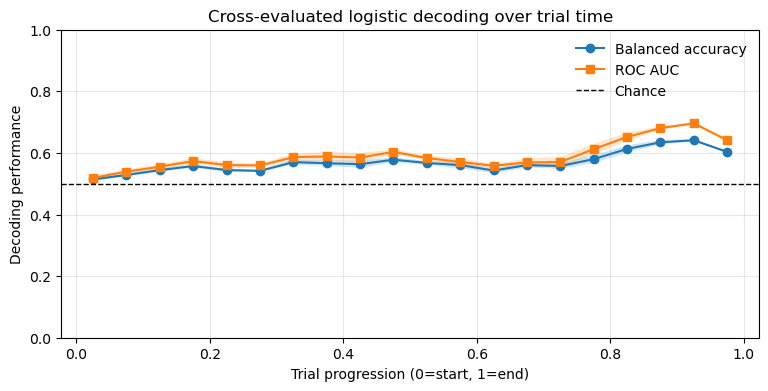

,time_bin,time_mid,time_from_start_mean,n_samples,bal_acc_mean,bal_acc_sem,auc_mean,auc_sem
0,0,0.025,2.400944e+05,20212,0.514330,0.006678,0.519069,0.008058
1,1,0.075,7.475742e+05,15811,0.528382,0.004109,0.539187,0.006775
2,2,0.125,1.062541e+06,15824,0.544327,0.006560,0.555333,0.008573
3,3,0.175,1.426719e+06,12149,0.557379,0.004997,0.573492,0.008845
4,4,0.225,1.853552e+06,9006,0.544319,0.005710,0.560611,0.009729
5,5,0.275,2.210102e+06,7466,0.541700,0.003806,0.559205,0.006182
6,6,0.325,2.507250e+06,7303,0.570137,0.007928,0.586302,0.011252
7,7,0.375,2.781092e+06,7719,0.566549,0.009301,0.588623,0.013597
8,8,0.425,3.044193e+06,8042,0.563462,0.012072,0.585088,0.014478
9,9,0.475,3.294431e+06,7886,0.577978,0.008344,0.603367,0.008467


In [24]:
# Time-resolved performance across evaluation trials using from_ephys_timestamp.
n_time_bins = 20
bin_edges = np.linspace(0.0, 1.0, n_time_bins + 1)

df_eval = df_dec[df_dec["oof_pred"].notna()].copy()
df_eval["time_bin"] = pd.cut(
    df_eval["trial_progress"],
    bins=bin_edges,
    include_lowest=True,
    labels=False,
)

rows = []
for (fold, tbin), g in df_eval.groupby(["oof_fold", "time_bin"], dropna=True):
    if g.empty:
        continue
    y_true = g["choice_R2_bin"].to_numpy()
    y_hat = g["oof_pred"].to_numpy()
    y_prob = g["oof_prob"].to_numpy()

    rows.append(
        {
            "oof_fold": int(fold),
            "time_bin": int(tbin),
            "time_mid": (int(tbin) + 0.5) / n_time_bins,
            "time_from_start_mean": float(g["time_from_trial_start"].mean()),
            "n_samples": int(len(g)),
            "accuracy": accuracy_score(y_true, y_hat),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_hat),
            "roc_auc": roc_auc_score(y_true, y_prob) if np.unique(y_true).size == 2 else np.nan,
        }
    )

time_bin_fold_metrics = pd.DataFrame(rows)
if time_bin_fold_metrics.empty:
    raise ValueError("No time-bin metrics could be computed.")

time_bin_summary = (
    time_bin_fold_metrics
    .groupby("time_bin", as_index=False)
    .agg(
        time_mid=("time_mid", "mean"),
        time_from_start_mean=("time_from_start_mean", "mean"),
        n_samples=("n_samples", "sum"),
        bal_acc_mean=("balanced_accuracy", "mean"),
        bal_acc_sem=("balanced_accuracy", "sem"),
        auc_mean=("roc_auc", "mean"),
        auc_sem=("roc_auc", "sem"),
    )
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    time_bin_summary["time_mid"],
    time_bin_summary["bal_acc_mean"],
    marker="o",
    label="Balanced accuracy",
)
ax.fill_between(
    time_bin_summary["time_mid"],
    (time_bin_summary["bal_acc_mean"] - time_bin_summary["bal_acc_sem"]).to_numpy(),
    (time_bin_summary["bal_acc_mean"] + time_bin_summary["bal_acc_sem"]).to_numpy(),
    alpha=0.2,
)

if time_bin_summary["auc_mean"].notna().any():
    ax.plot(
        time_bin_summary["time_mid"],
        time_bin_summary["auc_mean"],
        marker="s",
        label="ROC AUC",
    )
    ax.fill_between(
        time_bin_summary["time_mid"],
        (time_bin_summary["auc_mean"] - time_bin_summary["auc_sem"]).to_numpy(),
        (time_bin_summary["auc_mean"] + time_bin_summary["auc_sem"]).to_numpy(),
        alpha=0.2,
    )

ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="Chance")
ax.set_xlabel("Trial progression (0=start, 1=end)")
ax.set_ylabel("Decoding performance")
ax.set_title("Cross-evaluated logistic decoding over trial time")
ax.set_ylim(0.0, 1.0)
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.show()

time_bin_summary
